In [22]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import geodatasets
from shapely.geometry import Point

In [ ]:
df_vio = pd.read_csv("Violence_Reduction_-_Victims_of_Homicides_and_Non-Fatal_Shootings_20260302.csv")
df_vio.shape

(63245, 38)

In [31]:
df_stat = pd.read_csv("Public_Health_Statistics_-_Selected_public_health_indicators_by_Chicago_community_area_-_Historical_20260302.csv")
df_stat = df_stat.rename(columns={"Community Area Name": "COMMUNITY_AREA"})
df_stat["COMMUNITY_AREA"] = df_stat["COMMUNITY_AREA"].str.upper()
df_stat.shape

(77, 29)

In [25]:
df_merged = pd.merge(df_vio, df_stat, on="COMMUNITY_AREA")
df_merged.shape

(63126, 66)

In [28]:
df_parsed = df_merged.copy()

# Convert to datetime
df_parsed["DATE"] = pd.to_datetime(df_parsed["DATE"], format="%m/%d/%Y %I:%M:%S %p")

df_parsed["DATE_only"] = df_parsed["DATE"].dt.date
df_parsed["YEAR"] = df_parsed["DATE"].dt.year
df_parsed["TIME"] = df_parsed["DATE"].dt.time

df_parsed = df_parsed[(df_parsed["YEAR"] >= 2005) & (df_parsed["YEAR"] <= 2010)]

df_parsed.head(5)

df_parsed.to_csv("parsed.csv")

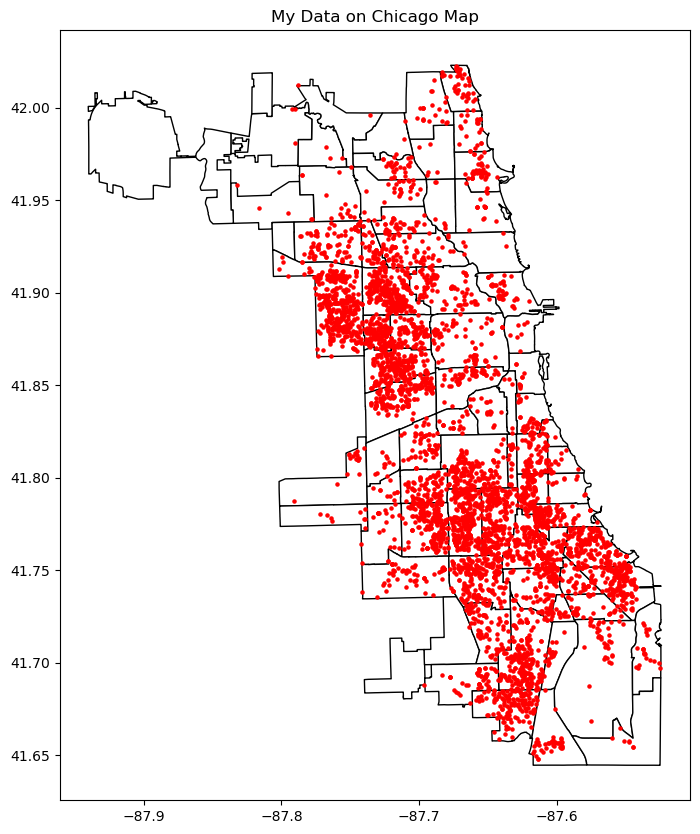

In [29]:
# Method comes from: https://chatgpt.com/c/69cb28e5-c134-832d-9061-cced1c1fb5e6
# Chicago polygons
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

df = pd.read_csv("parsed.csv")

geometry = [Point(xy) for xy in zip(df["LONGITUDE"], df["LATITUDE"])]

geo_df = gpd.GeoDataFrame(df, geometry=geometry)

geo_df.set_crs(epsg=4326, inplace=True)

geo_df = geo_df.to_crs(chicago.crs)

fig, ax = plt.subplots(figsize=(10, 10))

# Base map
chicago.plot(ax=ax, color="white", edgecolor="black")

# Your points
geo_df.plot(ax=ax, color="red", markersize=5)

plt.title("My Data on Chicago Map")
plt.show()